In [1]:
import sys, os
from pathlib import Path

PROJECT      = "/kaggle/working"
DATASET_ROOT = "/kaggle/input/datasets/surathbob/hiwaf-split-v1"

sys.path.insert(0, PROJECT)
sys.path.insert(0, DATASET_ROOT)   # ADDED: feature_engineering/ lives here, read-only, not copied to /kaggle/working
os.chdir(PROJECT)

for d in ["layer2b/candidates", "exported_models", "results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"Working dir: {os.getcwd()}")
print(f"sys.path includes: {PROJECT}, {DATASET_ROOT}")

Working dir: /kaggle/working
sys.path includes: /kaggle/working, /kaggle/input/datasets/surathbob/hiwaf-split-v1


In [14]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime skl2onnx onnxmltools \
             tqdm seaborn scipy pandas onnxscript

In [3]:
%%writefile /kaggle/working/layer2b/candidates/bigru.py
"""
layer2b/candidates/bigru.py

Layer 2B primary — Bidirectional GRU with Bahdanau Attention.
Architecture: Embedding -> BiGRU (2 layers) -> Bahdanau Attention -> Linear -> Softmax

CHANGED (CRC): renamed from gru.py/GRUModel to bigru.py/BiGRUModel — the
architecture itself was always correctly bidirectional (nn.GRU(...,
bidirectional=True) + attention sized for hidden_dim*2), the old filename
just undersold what was actually implemented and caused confusion about
whether the paper's "BiGRU" claim matched the code. It does.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]
NUM_CLASSES = len(CLASS_NAMES)
MAX_LEN     = 512

TRAIN_PARAMS = {
    "epochs": 45, "batch_size": 128, "lr": 3e-4, "weight_decay": 1e-5,
    "patience": 7, "embed_dim": 64, "hidden_dim": 128, "num_layers": 2,
    "dropout": 0.3, "grad_clip": 1.0,
}


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.w = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, gru_out: torch.Tensor):
        scores  = self.w(gru_out).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), gru_out).squeeze(1)
        return context, weights


class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=2, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attention  = BahdanauAttention(hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )

    def forward(self, x, return_attn: bool = False):
        emb = self.embed_drop(self.embedding(x))
        gru_out, _ = self.gru(emb)
        ctx, attn  = self.attention(gru_out)
        logits     = self.classifier(ctx)
        return (logits, attn) if return_attn else logits


class BiGRUModel:
    def __init__(self, vocab_size: int):
        self.vocab_size = vocab_size
        self.net = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

    def train(self, X_train, y_train, X_val, y_val, verbose_every=5):
        device = self.device
        print(f"[BiGRU] Training on {device}")

        tr_dl = DataLoader(
            TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long()),
            batch_size=TRAIN_PARAMS["batch_size"], shuffle=True, num_workers=2,
            pin_memory=(device == "cuda"),
        )
        v_dl = DataLoader(
            TensorDataset(torch.from_numpy(X_val).long(), torch.from_numpy(y_val).long()),
            batch_size=TRAIN_PARAMS["batch_size"], num_workers=2,
        )

        net = BiGRUClassifier(
            vocab_size=self.vocab_size, embed_dim=TRAIN_PARAMS["embed_dim"],
            hidden_dim=TRAIN_PARAMS["hidden_dim"], num_layers=TRAIN_PARAMS["num_layers"],
            dropout=TRAIN_PARAMS["dropout"],
        ).to(device)

        weights = _class_weights(y_train, NUM_CLASSES, device)
        crit = nn.CrossEntropyLoss(weight=weights)
        opt  = torch.optim.AdamW(net.parameters(), lr=TRAIN_PARAMS["lr"],
                                  weight_decay=TRAIN_PARAMS["weight_decay"])
        sch  = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=TRAIN_PARAMS["lr"] * 10,
            epochs=TRAIN_PARAMS["epochs"], steps_per_epoch=len(tr_dl),
        )

        best_f1, patience_ctr, best_state = 0.0, 0, None
        history = []

        for epoch in range(1, TRAIN_PARAMS["epochs"] + 1):
            net.train()
            tr_loss = 0.0
            for xb, yb in tr_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(net(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), TRAIN_PARAMS["grad_clip"])
                opt.step()
                sch.step()
                tr_loss += loss.item()
            tr_loss /= len(tr_dl)

            val_f1, val_acc, per_class_f1 = _validate(net, v_dl, device)
            history.append({"epoch": epoch, "train_loss": tr_loss, "val_f1": val_f1, "val_acc": val_acc})

            if epoch % verbose_every == 0:
                print(f"  epoch {epoch:3d} | loss={tr_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f}")

            if val_f1 > best_f1:
                best_f1, patience_ctr = val_f1, 0
                best_state = {k: v.clone() for k, v in net.state_dict().items()}
            else:
                patience_ctr += 1
                if patience_ctr >= TRAIN_PARAMS["patience"]:
                    print(f"[BiGRU] Early stopping at epoch {epoch}")
                    break

        net.load_state_dict(best_state)
        self.net = net
        self.history = history
        print(f"[BiGRU] Best val macro-F1: {best_f1:.4f}")
        return best_f1

    def predict(self, X):
        self.net.eval()
        preds = []
        with torch.no_grad():
            for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X).long()), batch_size=256):
                preds.append(self.net(xb.to(self.device)).argmax(1).cpu().numpy())
        return np.concatenate(preds)

    def predict_proba(self, X):
        self.net.eval()
        probs = []
        with torch.no_grad():
            for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X).long()), batch_size=256):
                probs.append(F.softmax(self.net(xb.to(self.device)), dim=1).cpu().numpy())
        return np.concatenate(probs)

    def attention_map(self, token_ids, tokenizer):
        self.net.eval()
        x = torch.from_numpy(token_ids).long().to(self.device)
        with torch.no_grad():
            _, weights = self.net(x, return_attn=True)
        weights = weights[0].cpu().numpy()
        text = tokenizer.decode(token_ids[0])
        return [(ch, round(float(w), 5)) for ch, w in zip(text, weights[:len(text)])]

    def export_onnx(self, output_path: str):
        self.net.eval().cpu()
        dummy = torch.zeros(1, MAX_LEN, dtype=torch.long)
        torch.onnx.export(
            self.net, dummy, output_path,
            input_names=["token_ids"], output_names=["logits"],
            dynamic_axes={"token_ids": {0: "batch"}, "logits": {0: "batch"}},
            opset_version=17,
        )
        self.net.to(self.device)
        print(f"[BiGRU] ONNX exported -> {output_path}")


def _class_weights(y, n_classes, device):
    counts  = np.bincount(y, minlength=n_classes).astype(float)
    weights = 1.0 / (counts + 1)
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def _validate(net, dl, device):
    from sklearn.metrics import f1_score, accuracy_score
    net.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in dl:
            preds.extend(net(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    f1  = f1_score(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    per_class_f1 = f1_score(labels, preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    return float(f1), float(acc), per_class_f1

Writing /kaggle/working/layer2b/candidates/bigru.py


In [4]:
%%writefile /kaggle/working/layer2b/candidates/cnn_1d.py
"""
layer2b/candidates/cnn_1d.py

Layer 2B comparison candidate — 1D CNN over character token sequences.
Reported alongside BiGRU as an accuracy/latency trade-off comparison
(per CRC strategy: never a replacement candidate for the accepted
architecture, regardless of how it scores).
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]
NUM_CLASSES = len(CLASS_NAMES)
MAX_LEN     = 512

TRAIN_PARAMS = {
    "epochs": 40, "batch_size": 128, "lr": 5e-4, "weight_decay": 1e-5,
    "patience": 6, "embed_dim": 64, "num_filters": 128,
    "kernel_sizes": [3, 5, 7], "dropout": 0.3, "grad_clip": 1.0,
}


class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_filters=128,
                 kernel_sizes=(3, 5, 7), num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k // 2) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(num_filters * len(kernel_sizes), 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)          # (B, E, L)
        pooled = [F.relu(conv(emb)).max(dim=2).values for conv in self.convs]  # each (B, F)
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.classifier(cat)


class CNN1DModel:
    def __init__(self, vocab_size: int):
        self.vocab_size = vocab_size
        self.net = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

    def train(self, X_train, y_train, X_val, y_val, verbose_every=5):
        device = self.device
        print(f"[CNN1D] Training on {device}")

        tr_dl = DataLoader(
            TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long()),
            batch_size=TRAIN_PARAMS["batch_size"], shuffle=True, num_workers=2,
            pin_memory=(device == "cuda"),
        )
        v_dl = DataLoader(
            TensorDataset(torch.from_numpy(X_val).long(), torch.from_numpy(y_val).long()),
            batch_size=TRAIN_PARAMS["batch_size"], num_workers=2,
        )

        net = CNN1DClassifier(
            vocab_size=self.vocab_size, embed_dim=TRAIN_PARAMS["embed_dim"],
            num_filters=TRAIN_PARAMS["num_filters"], kernel_sizes=TRAIN_PARAMS["kernel_sizes"],
            dropout=TRAIN_PARAMS["dropout"],
        ).to(device)

        weights = _class_weights(y_train, NUM_CLASSES, device)
        crit = nn.CrossEntropyLoss(weight=weights)
        opt  = torch.optim.AdamW(net.parameters(), lr=TRAIN_PARAMS["lr"], weight_decay=TRAIN_PARAMS["weight_decay"])

        best_f1, patience_ctr, best_state = 0.0, 0, None
        for epoch in range(1, TRAIN_PARAMS["epochs"] + 1):
            net.train()
            tr_loss = 0.0
            for xb, yb in tr_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(net(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(), TRAIN_PARAMS["grad_clip"])
                opt.step()
                tr_loss += loss.item()
            tr_loss /= len(tr_dl)

            val_f1, val_acc = _validate(net, v_dl, device)
            if epoch % verbose_every == 0:
                print(f"  epoch {epoch:3d} | loss={tr_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f}")

            if val_f1 > best_f1:
                best_f1, patience_ctr = val_f1, 0
                best_state = {k: v.clone() for k, v in net.state_dict().items()}
            else:
                patience_ctr += 1
                if patience_ctr >= TRAIN_PARAMS["patience"]:
                    print(f"[CNN1D] Early stopping at epoch {epoch}")
                    break

        net.load_state_dict(best_state)
        self.net = net
        print(f"[CNN1D] Best val macro-F1: {best_f1:.4f}")
        return best_f1

    def predict(self, X):
        self.net.eval()
        preds = []
        with torch.no_grad():
            for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X).long()), batch_size=256):
                preds.append(self.net(xb.to(self.device)).argmax(1).cpu().numpy())
        return np.concatenate(preds)

    def predict_proba(self, X):
        self.net.eval()
        probs = []
        with torch.no_grad():
            for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X).long()), batch_size=256):
                probs.append(F.softmax(self.net(xb.to(self.device)), dim=1).cpu().numpy())
        return np.concatenate(probs)

    def export_onnx(self, output_path: str):
        self.net.eval().cpu()
        dummy = torch.zeros(1, MAX_LEN, dtype=torch.long)
        torch.onnx.export(
            self.net, dummy, output_path,
            input_names=["token_ids"], output_names=["logits"],
            dynamic_axes={"token_ids": {0: "batch"}, "logits": {0: "batch"}},
            opset_version=17,
        )
        self.net.to(self.device)
        print(f"[CNN1D] ONNX exported -> {output_path}")


def _class_weights(y, n_classes, device):
    counts  = np.bincount(y, minlength=n_classes).astype(float)
    weights = 1.0 / (counts + 1)
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def _validate(net, dl, device):
    from sklearn.metrics import f1_score, accuracy_score
    net.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in dl:
            preds.extend(net(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return f1_score(labels, preds, average="macro", zero_division=0), accuracy_score(labels, preds)

Writing /kaggle/working/layer2b/candidates/cnn_1d.py


In [5]:
%%writefile /kaggle/working/layer2b/candidates/xgboost_model.py
"""
layer2b/candidates/xgboost_model.py
Layer 2B baseline candidate — XGBoost on the 29-dim numeric feature vector.
Reported in Table II as a baseline, not a competing headline candidate.
"""

import numpy as np
import xgboost as xgb

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]
NUM_CLASSES = len(CLASS_NAMES)


class XGBoostModel:
    def __init__(self):
        self.model = None

    def train(self, X_train, y_train, X_val, y_val):
        sample_weight = _sample_weights(y_train, NUM_CLASSES)
        self.model = xgb.XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.1,
            objective="multi:softprob", num_class=NUM_CLASSES,
            eval_metric="mlogloss", early_stopping_rounds=30,
            n_jobs=-1, random_state=42,
        )
        self.model.fit(
            X_train, y_train, sample_weight=sample_weight,
            eval_set=[(X_val, y_val)], verbose=100,
        )
        print(f"[XGBoost] Best iter={self.model.best_iteration}")

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def feature_importance(self, feature_names):
        importances = self.model.feature_importances_
        return dict(sorted(zip(feature_names, importances), key=lambda x: -x[1]))

    def export_onnx(self, output_path: str, input_dim: int):
        from onnxmltools import convert_xgboost
        from onnxmltools.convert.common.data_types import FloatTensorType
        onnx_model = convert_xgboost(self.model, initial_types=[("input", FloatTensorType([None, input_dim]))])
        with open(output_path, "wb") as f:
            f.write(onnx_model.SerializeToString())
        print(f"[XGBoost] ONNX exported -> {output_path}")


def _sample_weights(y, n_classes):
    counts = np.bincount(y, minlength=n_classes).astype(float)
    class_w = counts.sum() / (n_classes * (counts + 1))
    return class_w[y]

Writing /kaggle/working/layer2b/candidates/xgboost_model.py


In [6]:
from pathlib import Path

for p in Path("/kaggle/input/datasets/surathbob/hiwaf-split-v1/feature_engineering").iterdir():
    print(repr(p.name))

'normalizer.py'
'tokenizer.py'
'__init__.py'
'extractor.py'


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path

from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

from feature_engineering.extractor import INPUT_DIM
from feature_engineering.tokenizer import VOCAB_SIZE, CharTokenizer
from layer2b.candidates.bigru import BiGRUModel, CLASS_NAMES, NUM_CLASSES
from layer2b.candidates.cnn_1d import CNN1DModel
from layer2b.candidates.xgboost_model import XGBoostModel

import random, torch, tensorflow as tf
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_SPLITS = Path("/kaggle/input/datasets/surathbob/hiwaf-split-v1/data/splits")
MODEL_DIR   = Path("/kaggle/working/exported_models")
RESULTS_DIR = Path("/kaggle/working/results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_DIM == 29, f"Expected INPUT_DIM=29, got {INPUT_DIM}"

SWEEP_POINTS = ["all", "10k", "8k", "6k", "5k"]

sweep_data = {}
for sp in SWEEP_POINTS:
    sweep_data[sp] = {
        "X_num": np.load(DATA_SPLITS / f"l2b_train_X_numeric_sqli{sp}.npy"),
        "X_tok": np.load(DATA_SPLITS / f"l2b_train_X_tokens_sqli{sp}.npy"),
        "y":     np.load(DATA_SPLITS / f"l2b_train_y_sqli{sp}.npy"),
    }
    assert sweep_data[sp]["X_num"].shape[1] == 29, f"sweep '{sp}' numeric features not 29-dim — stale data?"

X_val_num,  y_val  = np.load(DATA_SPLITS / "l2b_val_X_numeric.npy"),  np.load(DATA_SPLITS / "l2b_val_y.npy")
X_val_tok           = np.load(DATA_SPLITS / "l2b_val_X_tokens.npy")
X_test_num, y_test  = np.load(DATA_SPLITS / "l2b_test_X_numeric.npy"), np.load(DATA_SPLITS / "l2b_test_y.npy")
X_test_tok           = np.load(DATA_SPLITS / "l2b_test_X_tokens.npy")

assert X_val_num.shape[1] == 29 and X_test_num.shape[1] == 29, "val/test numeric features not 29-dim"

print("Splits loaded. Sweep point sizes:")
for sp in SWEEP_POINTS:
    print(f"  {sp:>4}: {sweep_data[sp]['X_num'].shape[0]} rows")
print(f"Val: {X_val_num.shape}  Test: {X_test_num.shape}")
print(f"VOCAB_SIZE: {VOCAB_SIZE}")

Splits loaded. Sweep point sizes:
   all: 18070 rows
   10k: 18070 rows
    8k: 17058 rows
    6k: 15058 rows
    5k: 14058 rows
Val: (3956, 29)  Test: (3693, 29)
VOCAB_SIZE: 99


In [8]:
# Selection rule: best validation macro-F1, but reject any sweep point where
# xss (smallest, most fragile class, id=2) per-class F1 drops more than 2
# points below the 'all' sweep point's xss F1 — more sqli data should not be
# allowed to quietly starve the smallest class even if macro-F1 looks fine.

bigru_sweep_results = {}
bigru_sweep_models  = {}

for sp in SWEEP_POINTS:
    print(f"\n{'='*60}\n[BiGRU sweep: sqli={sp}]\n{'='*60}")
    model = BiGRUModel(vocab_size=VOCAB_SIZE + 1)
    val_f1 = model.train(sweep_data[sp]["X_tok"], sweep_data[sp]["y"], X_val_tok, y_val)

    val_preds = model.predict(X_val_tok)
    per_class_f1 = f1_score(y_val, val_preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))

    bigru_sweep_results[sp] = {
        "macro_f1": val_f1,
        "xss_f1": float(per_class_f1[2]),
        "per_class_f1": per_class_f1.tolist(),
    }
    bigru_sweep_models[sp] = model

sweep_summary = pd.DataFrame([
    {"sweep_point": sp, "macro_f1": r["macro_f1"], "xss_f1": r["xss_f1"]}
    for sp, r in bigru_sweep_results.items()
])
print("\nSweep summary:")
print(sweep_summary.to_string(index=False))

baseline_xss_f1 = bigru_sweep_results["all"]["xss_f1"]
sweep_summary["xss_f1_ok"] = sweep_summary["xss_f1"] >= (baseline_xss_f1 - 0.02)

eligible = sweep_summary[sweep_summary["xss_f1_ok"]]
best_sp_row = eligible.sort_values("macro_f1", ascending=False).iloc[0]
best_sweep_point = best_sp_row["sweep_point"]

print(f"\nSelected sweep point: '{best_sweep_point}' "
      f"(macro_f1={best_sp_row['macro_f1']:.4f}, xss_f1={best_sp_row['xss_f1']:.4f}, "
      f"baseline_xss_f1={baseline_xss_f1:.4f})")

sweep_summary.to_csv(RESULTS_DIR / "bigru_sqli_sweep_summary.csv", index=False)

bigru_final = bigru_sweep_models[best_sweep_point]
X_train_num_final = sweep_data[best_sweep_point]["X_num"]
X_train_tok_final = sweep_data[best_sweep_point]["X_tok"]
y_train_final      = sweep_data[best_sweep_point]["y"]


[BiGRU sweep: sqli=all]
[BiGRU] Training on cuda
  epoch   5 | loss=0.1663 | val_f1=0.9328 | val_acc=0.9479
  epoch  10 | loss=0.0670 | val_f1=0.9777 | val_acc=0.9833
  epoch  15 | loss=0.0282 | val_f1=0.9880 | val_acc=0.9914
  epoch  20 | loss=0.0216 | val_f1=0.9884 | val_acc=0.9917
[BiGRU] Early stopping at epoch 21
[BiGRU] Best val macro-F1: 0.9910

[BiGRU sweep: sqli=10k]
[BiGRU] Training on cuda
  epoch   5 | loss=0.1612 | val_f1=0.9527 | val_acc=0.9633
  epoch  10 | loss=0.0501 | val_f1=0.9802 | val_acc=0.9853
  epoch  15 | loss=0.0291 | val_f1=0.9845 | val_acc=0.9891
  epoch  20 | loss=0.0218 | val_f1=0.9876 | val_acc=0.9909
[BiGRU] Early stopping at epoch 21
[BiGRU] Best val macro-F1: 0.9877

[BiGRU sweep: sqli=8k]
[BiGRU] Training on cuda
  epoch   5 | loss=0.1728 | val_f1=0.9499 | val_acc=0.9603
  epoch  10 | loss=0.0469 | val_f1=0.9846 | val_acc=0.9884
  epoch  15 | loss=0.0244 | val_f1=0.9888 | val_acc=0.9922
  epoch  20 | loss=0.0189 | val_f1=0.9865 | val_acc=0.9904
  epo

In [9]:
print(f"Training comparison candidates on sweep point '{best_sweep_point}' "
      f"({len(y_train_final)} rows) — same data BiGRU's final result uses.\n")

cnn_model = CNN1DModel(vocab_size=VOCAB_SIZE + 1)
cnn_model.train(X_train_tok_final, y_train_final, X_val_tok, y_val)

xgb_model = XGBoostModel()
xgb_model.train(X_train_num_final, y_train_final, X_val_num, y_val)

Training comparison candidates on sweep point '8k' (17058 rows) — same data BiGRU's final result uses.

[CNN1D] Training on cuda
  epoch   5 | loss=0.0550 | val_f1=0.9842 | val_acc=0.9886
  epoch  10 | loss=0.0261 | val_f1=0.9864 | val_acc=0.9904
  epoch  15 | loss=0.0137 | val_f1=0.9841 | val_acc=0.9884
[CNN1D] Early stopping at epoch 17
[CNN1D] Best val macro-F1: 0.9866
[0]	validation_0-mlogloss:1.41131
[100]	validation_0-mlogloss:0.10658
[200]	validation_0-mlogloss:0.09063
[300]	validation_0-mlogloss:0.08717
[363]	validation_0-mlogloss:0.08701
[XGBoost] Best iter=333


In [10]:
def evaluate_l2b(name, model, X_test, y_test):
    preds = model.predict(X_test)
    per_class_f1 = f1_score(y_test, preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
    row = {
        "Model": name,
        "Macro_F1": f1_score(y_test, preds, average="macro", zero_division=0),
        "Accuracy": accuracy_score(y_test, preds),
    }
    for i, cls in enumerate(CLASS_NAMES):
        row[f"F1_{cls}"] = per_class_f1[i]
    return row, preds

bigru_row, bigru_preds = evaluate_l2b("BiGRU (headline)", bigru_final, X_test_tok, y_test)
cnn_row,   cnn_preds   = evaluate_l2b("CNN-1D",           cnn_model,   X_test_tok, y_test)
xgb_row,   xgb_preds   = evaluate_l2b("XGBoost",          xgb_model,   X_test_num, y_test)

table2 = pd.DataFrame([bigru_row, cnn_row, xgb_row])
table2.to_csv(RESULTS_DIR / "table2_l2b_candidate_comparison.csv", index=False)

print(f"Table II — Layer 2B Candidate Comparison (sweep point: '{best_sweep_point}')")
print(table2.to_string(index=False))

# NOTE: BiGRU is the fixed headline result regardless of this table's ranking
# — CNN-1D and XGBoost are reported as accuracy/latency trade-off context,
# never as competing "winner" candidates. Per CRC lock: no architecture swap.
print(f"\nHeadline model (fixed, not selected by this comparison): BiGRU")

print("\nBiGRU classification report (test set):")
print(classification_report(y_test, bigru_preds, target_names=CLASS_NAMES, zero_division=0))

Table II — Layer 2B Candidate Comparison (sweep point: '8k')
           Model  Macro_F1  Accuracy  F1_normal  F1_sqli   F1_xss   F1_lfi  F1_other_attack
BiGRU (headline)  0.992929  0.995397   0.991736 0.998963 0.991119 0.994401         0.988426
          CNN-1D  0.983640  0.989439   0.976288 0.998704 0.984127 0.994376         0.964706
         XGBoost  0.930635  0.952071   0.877586 0.994813 0.976577 0.971047         0.833152

Headline model (fixed, not selected by this comparison): BiGRU

BiGRU classification report (test set):
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99       603
        sqli       1.00      1.00      1.00      1929
         xss       0.99      1.00      0.99       280
         lfi       1.00      0.99      0.99       447
other_attack       0.99      0.98      0.99       434

    accuracy                           1.00      3693
   macro avg       0.99      0.99      0.99      3693
weighted avg       1.00      1.0

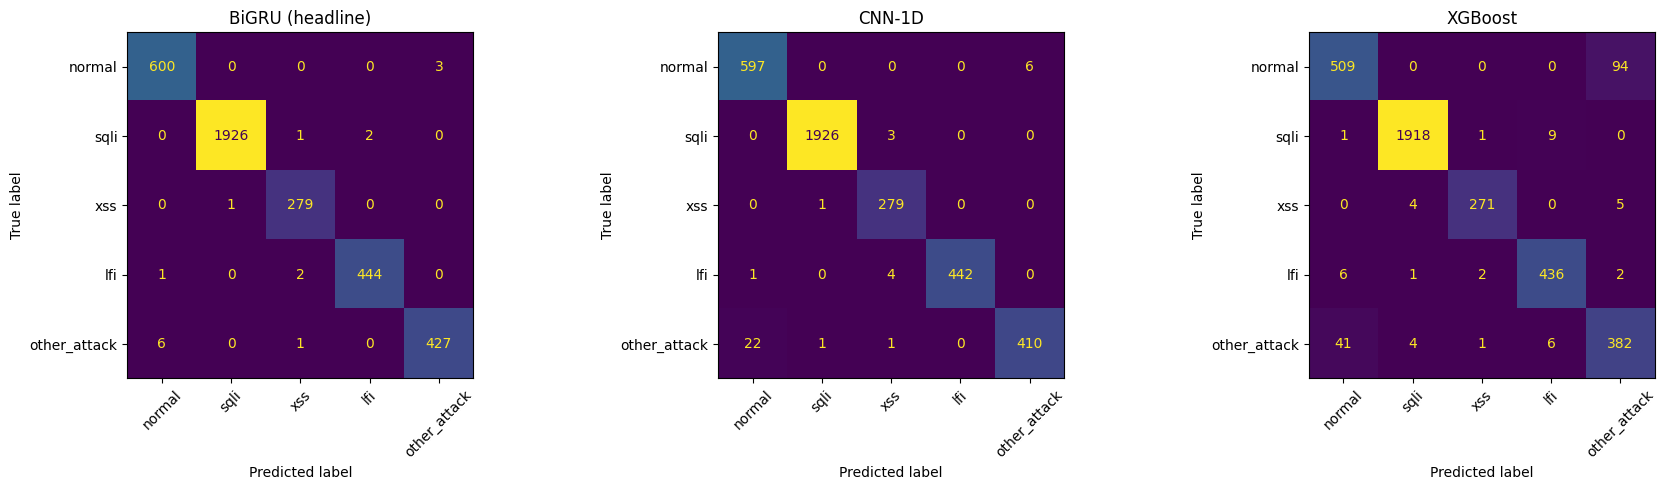

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, [
    ("BiGRU (headline)", bigru_preds), ("CNN-1D", cnn_preds), ("XGBoost", xgb_preds),
]):
    cm = confusion_matrix(y_test, preds, labels=list(range(NUM_CLASSES)))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "l2b_confusion_matrices.png", dpi=120)
plt.show()

In [12]:
def bootstrap_ci_l2b(y_true, y_pred, n_bootstrap=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    macro_f1s, accs = [], []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        macro_f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        accs.append(accuracy_score(yt, yp))

    def ci(vals):
        vals = np.array(vals)
        return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5)), float(np.mean(vals))

    return {"Macro_F1": ci(macro_f1s), "Accuracy": ci(accs)}

bigru_ci = bootstrap_ci_l2b(y_test, bigru_preds, n_bootstrap=1000)
print("Bootstrap 95% CIs — BiGRU (n=1000 resamples)")
for metric, (lo, hi, mean) in bigru_ci.items():
    print(f"  {metric}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

with open(RESULTS_DIR / "l2b_bootstrap_ci.json", "w") as f:
    json.dump({"model": "BiGRU", "n_bootstrap": 1000,
               "ci": {k: {"mean": v[2], "ci_low": v[0], "ci_high": v[1]} for k, v in bigru_ci.items()}},
              f, indent=2)

Bootstrap 95% CIs — BiGRU (n=1000 resamples)
  Macro_F1: 0.9929  [0.9894, 0.9962]
  Accuracy: 0.9954  [0.9932, 0.9976]


In [15]:
import onnxruntime as ort

bigru_onnx_path = MODEL_DIR / "layer2b_bigru.onnx"
bigru_final.export_onnx(str(bigru_onnx_path))

cnn_onnx_path = MODEL_DIR / "layer2b_cnn1d.onnx"
cnn_model.export_onnx(str(cnn_onnx_path))

def benchmark_latency(onnx_path, X_sample, n_runs=300):
    sess = ort.InferenceSession(str(onnx_path))
    dummy = X_sample[:1].astype(np.int64)
    for _ in range(20):
        sess.run(None, {"token_ids": dummy})
    latencies = []
    for i in range(n_runs):
        x = X_sample[i % len(X_sample): i % len(X_sample) + 1].astype(np.int64)
        t0 = time.perf_counter()
        sess.run(None, {"token_ids": x})
        latencies.append((time.perf_counter() - t0) * 1000)
    latencies = np.array(latencies)
    return {"mean_ms": float(latencies.mean()), "p50_ms": float(np.percentile(latencies, 50)),
            "p95_ms": float(np.percentile(latencies, 95)), "p99_ms": float(np.percentile(latencies, 99)), "n_runs": n_runs}

bigru_latency = benchmark_latency(bigru_onnx_path, X_test_tok)
cnn_latency   = benchmark_latency(cnn_onnx_path, X_test_tok)

print("BiGRU latency:", bigru_latency)
print("CNN-1D latency:", cnn_latency)

with open(RESULTS_DIR / "l2b_latency_benchmark.json", "w") as f:
    json.dump({"bigru": bigru_latency, "cnn_1d": cnn_latency}, f, indent=2)

/kaggle/working/layer2b/candidates/bigru.py:169: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0808 19:49:01.339000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `BiGRUClassifier([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.gru._flat_weights[0], self.gru._flat_weights[1], self.gru._flat_weights[2], self.gru._flat_weights[3], self.gru._flat_weights[4], self.gru._flat_weights[5], self.gru._flat_weights[6], self.gru._flat_weights[7], self.gru._flat_weights[8], self.gru._flat_weights[9], self.gru._flat_weights[10], self.gru._flat_weights[11], self.gru._flat_weights[12], self.gru._flat_weights[13], self.gru._flat_weights[14], self.gru._flat_weights[15] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `BiGRUClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/kaggle/working/layer2b/candidates/cnn_1d.py:129: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0808 19:51:20.431000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[BiGRU] ONNX exported -> /kaggle/working/exported_models/layer2b_bigru.onnx
[torch.onnx] Obtain model graph for `CNN1DClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN1DClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[CNN1D] ONNX exported -> /kaggle/working/exported_models/layer2b_cnn1d.onnx
BiGRU latency: {'mean_ms': 10.827746053335735, 'p50_ms': 10.798910500170678, 'p95_ms': 11.591341950133938, 'p99_ms': 12.041719250069036, 'n_runs': 300}
CNN-1D latency: {'mean_ms': 0.7769801233507678, 'p50_ms': 0.7681480001338059, 'p95_ms': 0.8775217500669896, 'p99_ms': 0.9403409198921503, 'n_runs': 300}


In [16]:
tok = CharTokenizer(max_len=512)
print("=== BiGRU Attention Map — Explainability Demo ===\n")

for target_class in [1, 2, 3, 4]:
    class_indices = np.where(y_test == target_class)[0]
    if len(class_indices) == 0:
        continue
    idx = class_indices[0]
    token_ids = X_test_tok[idx:idx+1]
    char_weights = bigru_final.attention_map(token_ids, tok)

    print(f"--- {CLASS_NAMES[target_class].upper()} sample ---")
    text = tok.decode(token_ids[0])[:80]
    print(f"  Request: {text}")
    skip = set(' qQ?=/&+GET POST')
    meaningful = [(ch, w) for ch, w in char_weights if ch not in skip and w > 0.001]
    top10 = sorted(meaningful, key=lambda x: x[1], reverse=True)[:10]
    for ch, w in top10:
        bar = "█" * min(int(w * 300), 40)
        print(f"    '{ch}'  {bar}  ({w:.4f})")
    print()

=== BiGRU Attention Map — Explainability Demo ===

--- SQLI sample ---
  Request: GET /?q=-2790%") union all select 5070,5070 nan
    '%'  ████████████████████████████████████████  (0.1443)
    '0'  ███████████████████████████████████  (0.1179)
    '9'  ███████████████████████████  (0.0910)
    '"'  ███████████████████████  (0.0787)
    ')'  ██████████████████  (0.0613)
    '7'  ███████████████  (0.0501)
    '2'  ████████████  (0.0417)
    'u'  █████████  (0.0327)
    'n'  █████████  (0.0310)
    'n'  ████████  (0.0273)

--- XSS sample ---
  Request: GET /?q=<object classid=clsid:ae24fdae-03c6-11d1-8b76-0080c744f389><param name=u
    '4'  █████  (0.0170)
    'c'  █████  (0.0170)
    'r'  ████  (0.0164)
    '4'  ████  (0.0162)
    'e'  ████  (0.0161)
    'm'  ████  (0.0160)
    'r'  ████  (0.0160)
    'c'  ████  (0.0159)
    '9'  ████  (0.0152)
    '8'  ████  (0.0150)

--- LFI sample ---
  Request: GET /?input=..`` nan
    '.'  ███████████████████████████████████  (0.1188)
    '.'  ████

In [17]:
import joblib
xgb_model.model.save_model(str(MODEL_DIR / "xgboost_l2b.json"))

metadata = {
    "headline_model": "BiGRU",
    "selected_sweep_point": best_sweep_point,
    "sweep_selection_rule": "best validation macro-F1, subject to xss F1 not dropping >0.02 below the 'all' sweep point",
    "input_dim_numeric": 29,
    "table2_comparison": table2.to_dict(orient="records"),
    "bigru_sweep_summary": sweep_summary.to_dict(orient="records"),
    "bootstrap_ci": {k: {"mean": v[2], "ci_low": v[0], "ci_high": v[1]} for k, v in bigru_ci.items()},
    "latency": {"bigru": bigru_latency, "cnn_1d": cnn_latency},
    "data_source": "hiwaf-processed-v1 (corrected: 5-class taxonomy, family-aware, domain-stripped, JSON/GraphQL features)",
}

with open(MODEL_DIR / "layer2b_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=lambda o: o.item() if isinstance(o, (np.floating, np.integer)) else str(o))

print("Saved:")
print(f"  {bigru_onnx_path}")
print(f"  {cnn_onnx_path}")
print(f"  {MODEL_DIR / 'xgboost_l2b.json'}")
print(f"  {MODEL_DIR / 'layer2b_metadata.json'}")
print(f"\nLayer 2B complete. Headline model: BiGRU (sweep point: '{best_sweep_point}')")

Saved:
  /kaggle/working/exported_models/layer2b_bigru.onnx
  /kaggle/working/exported_models/layer2b_cnn1d.onnx
  /kaggle/working/exported_models/xgboost_l2b.json
  /kaggle/working/exported_models/layer2b_metadata.json

Layer 2B complete. Headline model: BiGRU (sweep point: '8k')
